In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("dataset/price_data.csv")
df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [12]:
df["date"]=pd.to_datetime(df["date"])
df.tail()


,date,avg_monthly_price
244,2025-05-01,14263
245,2025-06-01,14263
246,2025-07-01,16000
247,2025-08-01,15025
248,2025-09-01,15750


In [22]:
df.isnull().sum()
Q1=df["avg_monthly_price"].quantile(0.25)
Q3=df["avg_monthly_price"].quantile(0.75)
IQR=Q3-Q1
print(IQR)



3423.75


In [23]:
df_outlier=df[(df['avg_monthly_price']<(Q1-1.5*IQR)) | (df['avg_monthly_price']>(Q3+1.5*IQR))]
df=df[(df['avg_monthly_price']>=(Q1-1.5*IQR)) & (df['avg_monthly_price']<=(Q3+1.5*IQR))]


In [24]:
df_outlier.shape
df_outlier

,avg_monthly_price
date,
2024-03-01,15150
2024-08-01,15263
2025-08-01,15025


In [25]:
df["month"]=df.index.month
df["year"]=df.index.year

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train=df[:-12]
test=df[-12:]

model = SARIMAX(train['avg_monthly_price'], 
                order=(1,1,1), 
                seasonal_order=(1,1,1,12))

model_fit = model.fit()

c:\Users\am536\OneDrive\Documents\Forecast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\am536\OneDrive\Documents\Forecast\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


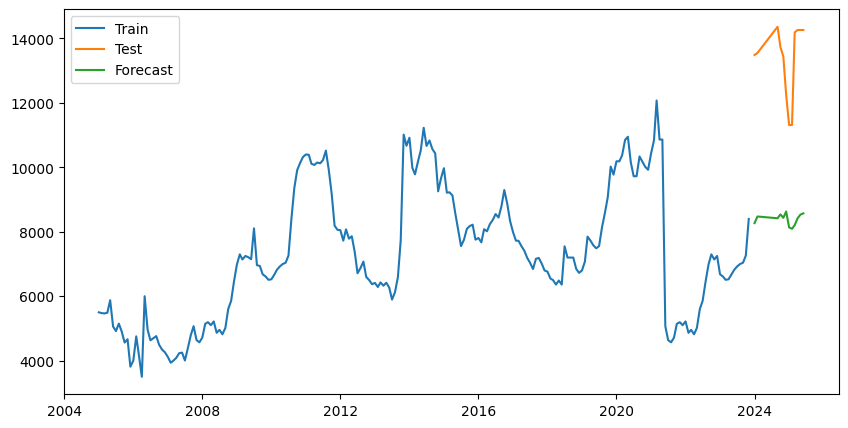

In [29]:
forecast = model_fit.forecast(steps=12)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train.index, train['avg_monthly_price'], label='Train')
plt.plot(test.index, test['avg_monthly_price'], label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

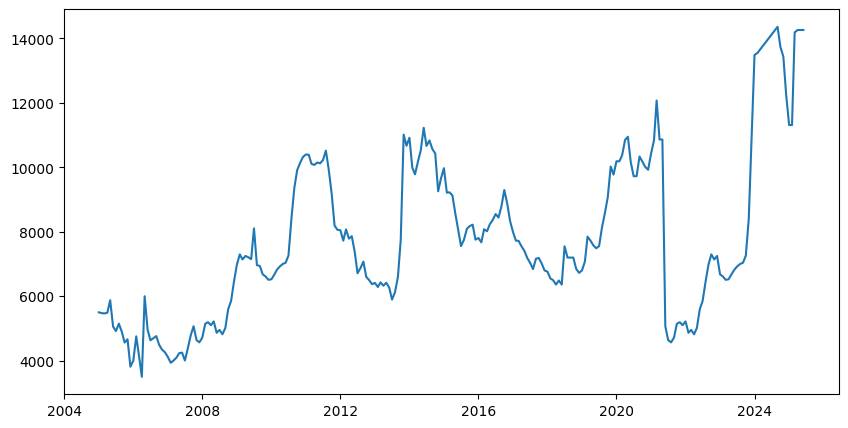

In [32]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df["avg_monthly_price"])
plt.show()


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['avg_monthly_price'], forecast)
rmse = np.sqrt(mean_squared_error(test['avg_monthly_price'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4975.47894299289
RMSE: 5075.435051223064


In [33]:
df.reset_index(inplace=True)

In [ ]:
df.drop(columns=["month","year"],inplace=True)

KeyError: "['month', 'year'] not found in axis"

In [37]:
df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [40]:
from prophet import Prophet

model=Prophet()
prophet_df=df.rename(columns={"date":"ds","avg_monthly_price":"y"})
train=prophet_df[:-12]  
test=prophet_df[-12:]
model.fit(train)
future=model.make_future_dataframe(periods=12,freq="MS")
forecast=model.predict(future)




22:13:51 - cmdstanpy - INFO - Chain [1] start processing
22:13:52 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
train.shape
test.shape
forecast.shape

train.head()


,ds,y
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


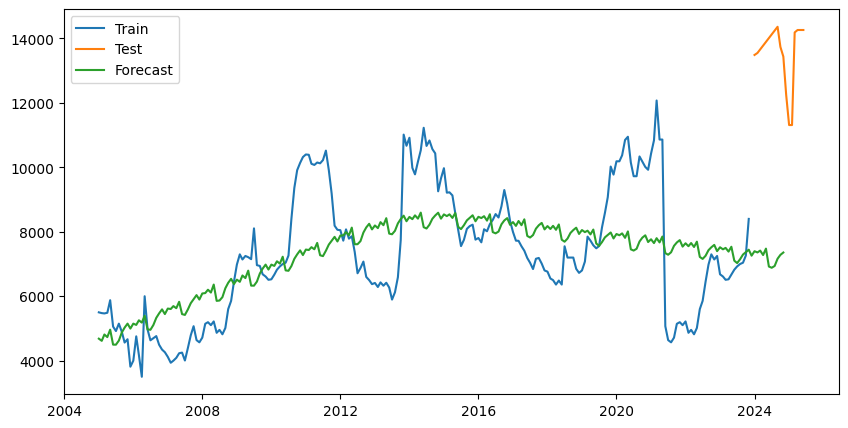

In [51]:
plt.figure(figsize=(10,5))
plt.plot(train["ds"],train["y"],label="Train")
plt.plot(test["ds"],test["y"],label="Test")
plt.plot(forecast["ds"],forecast["yhat"],label="Forecast")
plt.legend()
plt.show()









In [102]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(prophet_df["y"],forecast["yhat"]))

1486.4323431151


In [64]:
from sklearn.svm import SVR

svr_df=df.copy()
svr_df["month"]=df["date"].dt.month
svr_df["year"]=df["date"].dt.year
svr_df.head()

,date,avg_monthly_price,month,year
0,2005-01-01,5500,1,2005
1,2005-02-01,5476,2,2005
2,2005-03-01,5466,3,2005
3,2005-04-01,5487,4,2005
4,2005-05-01,5876,5,2005


In [66]:
Q1=svr_df["avg_monthly_price"].quantile(0.25)
Q3=svr_df["avg_monthly_price"].quantile(0.75)
IQR=Q3-Q1

svr_df_outlier=svr_df[(svr_df["avg_monthly_price"]<(Q1- 1.5*IQR)) | (svr_df["avg_monthly_price"]>(Q3+ 1.5*IQR))]
svr_df_outlier.head()

,date,avg_monthly_price,month,year
229,2024-09-01,14363,9,2024


In [70]:
svr_df=svr_df[(svr_df["avg_monthly_price"]>=(Q1- 1.5*IQR)) & (svr_df["avg_monthly_price"]<=(Q3+ 1.5*IQR))]

C:\Users\am536\AppData\Local\Temp\ipykernel_27696\3405177639.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


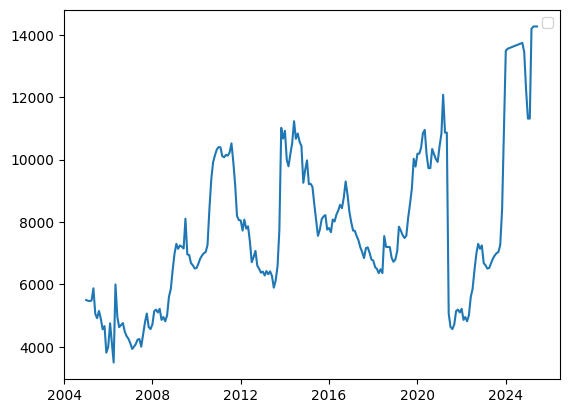

In [71]:
plt.figure()
plt.plot(svr_df["date"],svr_df["avg_monthly_price"])
plt.legend()
plt.show()

In [72]:
svr_df.describe()

,date,avg_monthly_price,month,year
count,238,238.000000,238.000000,238.000000
mean,2014-11-25 05:44:52.436974,7569.672269,6.415966,2014.449580
min,2005-01-01 00:00:00,3500.000000,1.000000,2005.000000
25%,2009-12-08 18:00:00,5881.000000,3.000000,2009.250000
50%,2014-11-16 00:00:00,7187.500000,6.000000,2014.000000
75%,2019-10-24 06:00:00,9222.250000,9.000000,2019.000000
max,2025-06-01 00:00:00,14263.000000,12.000000,2025.000000
std,NaN,2334.378487,3.479791,5.786969


In [84]:
svr_copy1=svr_df[svr_df["avg_monthly_price"]>Q3+1.5*IQR]
svr_copy2=svr_df[svr_df["avg_monthly_price"]<Q1-1.5*IQR]

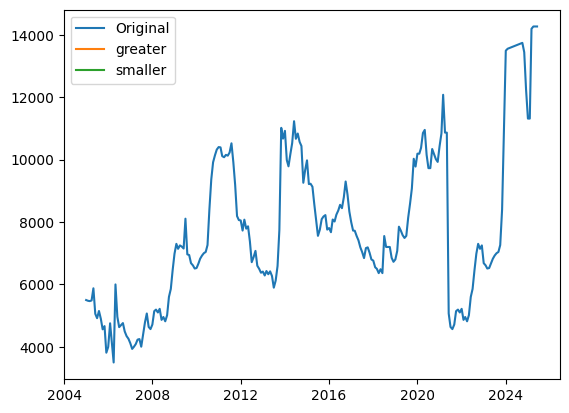

In [85]:
plt.figure()
plt.plot(svr_df["date"],svr_df["avg_monthly_price"],label="Original")
plt.plot(svr_copy1["date"],svr_copy1['avg_monthly_price'],label="greater")
plt.plot(svr_copy2["date"],svr_copy2['avg_monthly_price'],label="smaller")
plt.legend()
plt.show()

In [86]:
svr_df=svr_df[(svr_df["avg_monthly_price"]>=(Q1- 0.5*IQR)) & (svr_df["avg_monthly_price"]<=(Q3+ 0.5*IQR))]

C:\Users\am536\AppData\Local\Temp\ipykernel_27696\3405177639.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


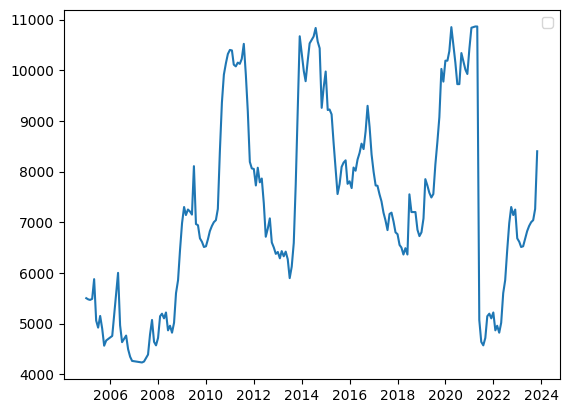

In [87]:
plt.figure()
plt.plot(svr_df["date"],svr_df["avg_monthly_price"])
plt.legend()
plt.show()

In [93]:
from sklearn.model_selection import train_test_split

svr_df.drop(columns=["date"])
X=svr_df.drop(columns=["avg_monthly_price","date"])
y=svr_df["avg_monthly_price"]
X["month"]=X["month"].astype(int)
X["year"]=X["year"].astype(int)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [94]:
X_train.head()

,month,year
44,9,2008
37,2,2008
51,4,2009
91,8,2012
111,4,2014


In [95]:
reg=SVR()
reg.fit(X_train,y_train)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [98]:
y_pred=reg.predict(X_test)



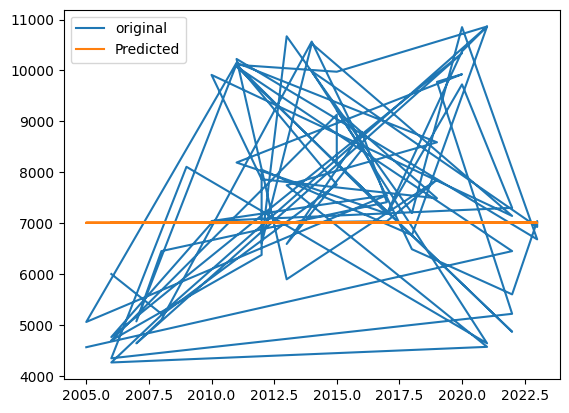

In [100]:
plt.figure()
plt.plot(X_test["year"],y_test,label="original")
plt.plot(X_test["year"],y_pred,label="Predicted")
plt.legend()
plt.show()

In [101]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

1709.9788251933185
4357944.654645828
